<div align="center">

# ***A Data-Driven Look at Digital Habits & Mental Well-being of Gen Z***
## 
###
###

<img src="https://miro.medium.com/v2/resize:fit:1120/1*J7M684vCMz0a2LWKrnGWzw.jpeg" width="1000">

##

#### In today's hyperconnected world, social media has transformed the way we interact with others and experience daily life. While it offers connection, entertainment, and self-expression, excessive use can also blur the line between healthy engagement and digital dependence. Through exploratory data analysis and visualizations, this project highlights meaningful patterns and insights within the data.
##
##





# Import All Libraries

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub


/kaggle/input/datasets/sharmajicoder/gen-z-social-media-usage-dataset/genz_social_media_usage_1M.csv


# 1. Understanding The Dataset

* ### Head

In [3]:
genz_social_media="/kaggle/input/datasets/sharmajicoder/gen-z-social-media-usage-dataset/genz_social_media_usage_1M.csv"
df = pd.read_csv(genz_social_media)

df.head(5)


,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


* ### Tail

In [38]:
df.tail(5)

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
999995,21,Male,India,3.097065,Snapchat,4,Entertainment,21.158532,1,7.230186,Medium,66.317438
999996,14,Male,India,3.663561,Instagram,1,Education,26.312119,1,8.273996,Medium,47.150600
999997,20,Male,India,4.474618,YouTube,2,Socializing,13.623681,0,7.611955,Medium,18.872826
999998,24,Female,Germany,7.829924,YouTube,2,Content Creation,15.789750,1,2.341113,High,62.136012
999999,13,Male,Canada,5.313645,TikTok,1,Socializing,26.397129,1,5.828090,High,34.892929


* ###  Information about Dataset

In [4]:
print("Dataset Shape:",df.shape)
df.info()
df.describe()


Dataset Shape: (1000000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   gender                    1000000 non-null  object 
 2   country                   1000000 non-null  object 
 3   daily_usage_hours         1000000 non-null  float64
 4   primary_platform          1000000 non-null  object 
 5   num_platforms_used        1000000 non-null  int64  
 6   purpose                   1000000 non-null  object 
 7   avg_session_minutes       1000000 non-null  float64
 8   night_usage               1000000 non-null  int64  
 9   mental_health_score       1000000 non-null  float64
 10  addiction_level           1000000 non-null  object 
 11  screen_time_before_sleep  1000000 non-null  float64
dtypes: float64(4), int64(3), object(5)
memory usage: 91.6+ M

,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,19.994629,3.514998,2.999469,25.088819,0.599958,7.170671,40.120754
std,4.322119,1.468771,1.414598,9.794249,0.489907,1.503885,19.569847
min,13.000000,0.500000,1.000000,5.000000,0.000000,1.000000,0.000000
25%,16.000000,2.493985,2.000000,18.257267,0.000000,6.147371,26.459592
50%,20.000000,3.503302,3.000000,25.002480,1.000000,7.198098,39.977162
75%,24.000000,4.513016,4.000000,31.759257,1.000000,8.243818,53.424345
max,27.000000,10.000000,5.000000,80.262224,1.000000,10.000000,137.998719


# 2. Data Structure & Data Quality 

## 2.1 Data Structure

* ### Columns

In [136]:
df.columns

Index(['age', 'gender', 'country', 'daily_usage_hours', 'primary_platform',
       'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage',
       'mental_health_score', 'addiction_level', 'screen_time_before_sleep'],
      dtype='object')

* ### Categorical Columns


In [138]:
categorical_cols = [
    'gender',
    'country',
    'primary_platform',
    'purpose',
    'addiction_level',
    'night_usage'
]

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())
    print("-" * 30)


gender
gender
Female    480113
Male      479576
Other      40311
Name: count, dtype: int64
------------------------------

country
country
India        350321
USA          199740
Canada       100384
UK           100343
Germany       99896
Brazil        99532
Australia     49784
Name: count, dtype: int64
------------------------------

primary_platform
primary_platform
Instagram    299927
YouTube      250292
TikTok       250085
Twitter      100022
Snapchat      99674
Name: count, dtype: int64
------------------------------

purpose
purpose
Entertainment       400052
Socializing         250239
Education           200367
News                 99693
Content Creation     49649
Name: count, dtype: int64
------------------------------

addiction_level
addiction_level
Medium    589843
Low       251220
High      158937
Name: count, dtype: int64
------------------------------

night_usage
night_usage
1    599958
0    400042
Name: count, dtype: int64
------------------------------


* ### Numerical Columns


In [12]:
numerical_cols =[
    'age',
    'daily_usage_hours',
    'num_platforms_used',
    'avg_session_minutes',
    'mental_health_score',
    'screen_time_before_sleep'
]

for col in numerical_cols:
    print(f"\n{col}")
    print("Min:",df[col].min())
    print("Max:",df[col].max())
    print("-" * 30)




age
Min: 13
Max: 27
------------------------------

daily_usage_hours
Min: 0.5
Max: 10.0
------------------------------

num_platforms_used
Min: 1
Max: 5
------------------------------

avg_session_minutes
Min: 5.0
Max: 80.26222433908394
------------------------------

mental_health_score
Min: 1.0
Max: 10.0
------------------------------

screen_time_before_sleep
Min: 0.0
Max: 137.9987192681989
------------------------------


In [140]:
df.nunique()

age                             15
gender                           3
country                          7
daily_usage_hours           977267
primary_platform                 5
num_platforms_used               5
purpose                          5
avg_session_minutes         977233
night_usage                      2
mental_health_score         967450
addiction_level                  3
screen_time_before_sleep    977324
dtype: int64

## 2.2 Data Quality Assessment

* ### Find Missing Values

In [141]:
 df.isnull().sum()

age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_session_minutes         0
night_usage                 0
mental_health_score         0
addiction_level             0
screen_time_before_sleep    0
dtype: int64

* ### Find Duplicate Values

In [142]:
 df.duplicated().sum()

np.int64(0)

### **Initial Observations**

* #### The dataset contains no missing values or duplicate records, so no data cleaning was required.
* #### The dataset contains both numerical and categorical variables.
* #### Categorical variables were checked for consistency, and no obvious inconsistencies were found.
* #### Numerical features were validated for logical ranges, and no invalid values were identified.
* #### Data types are appropriate for analysis, although some integer columns such as `night_usage` represent categorical variables conceptually.
* #### The `night_usage` feature contains only binary values (0 and 1).

* #### Overall, the dataset appears clean and ready for exploratory data analysis.
  

# 3. Exploratory Data Analysis and Visualizations

## 3.1 Univariate Analysis

* ### **Age Distribution Among Gen-Z Users**

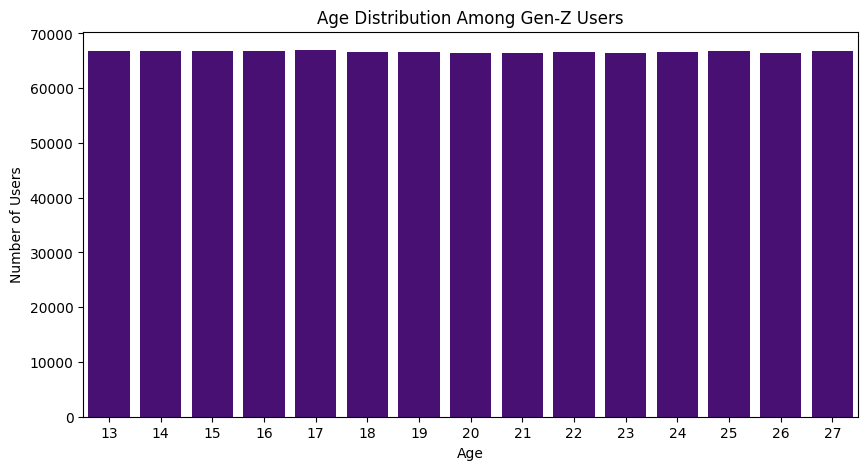

In [143]:
plt.figure(figsize=(10,5))

sns.countplot(
    data = df,
    x = 'age',
    color = 'indigo'
)

plt.title('Age Distribution Among Gen-Z Users')
plt.xlabel('Age')
plt.ylabel('Number of Users')
plt.show()

### **Insight:** 
#### The dataset includes users aged 13 to 27, with a nearly uniform distribution across all age groups. No particular age group dominates the dataset, indicating a balanced representation of Gen Z users by age.

* ### **Gender Distribution Among Gen-Z Users**

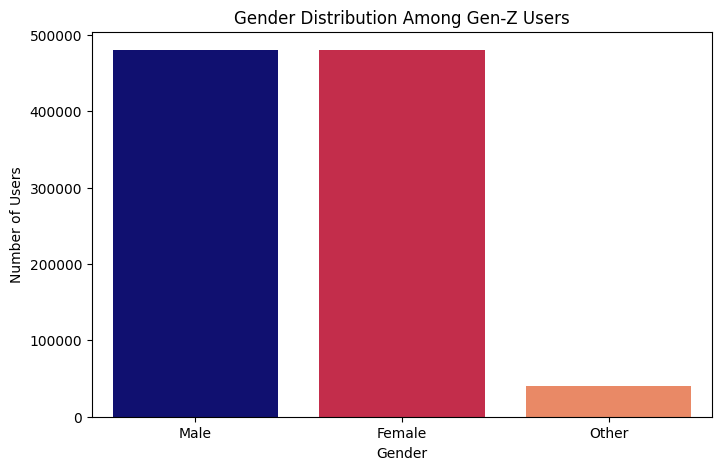

In [144]:
plt.figure(figsize=(8,5))

sns.countplot(
    data = df,
    x = 'gender',
    palette = ['navy','crimson','coral']
)

plt.title('Gender Distribution Among Gen-Z Users')
plt.xlabel('Gender')
plt.ylabel('Number of Users')
plt.show()


### **Insight:** 

* #### Male and Female users are almost equally represented in the dataset.
* #### The "Other" gender category has significantly fewer users compared to Male and Female.
* #### Overall, the gender distribution is balanced between the two major categories. 

* ### **Country Distribution Among Gen-Z Users**

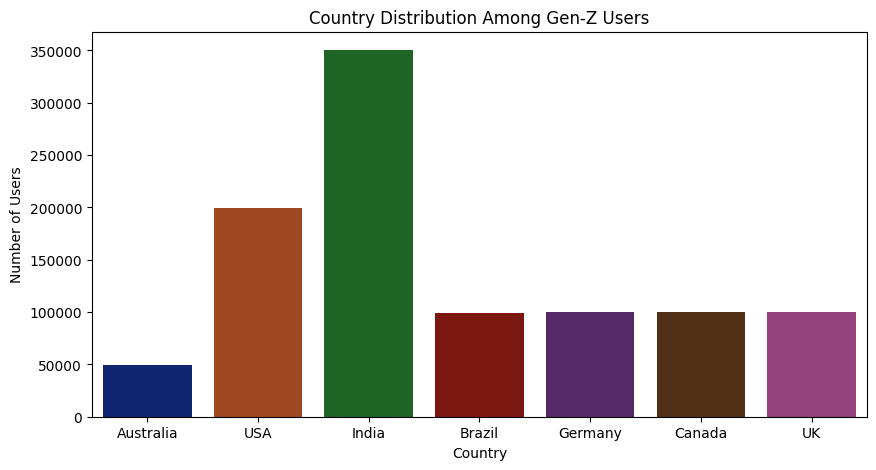

In [145]:
plt.figure(figsize=(10,5))

sns.countplot(
    data = df,
    x = 'country',
    palette='dark'
)

plt.title('Country Distribution Among Gen-Z Users')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.show()


### **Insight:** 
* #### India has the highest number of users in the dataset.
* #### The USA has the second-largest representation.
* #### Australia has the lowest number of users among all the countries.
* #### Brazil, Germany, Canada, and the UK have relatively similar user counts.

#### Overall, the dataset is geographically imbalanced, with India being significantly more represented than other countries.

* ### **Daily Social Media Usage Hours** 

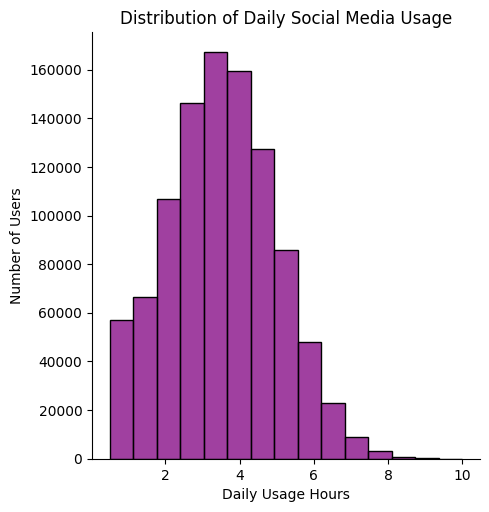

In [146]:
sns.displot(
    data = df,
    x='daily_usage_hours',
    bins = 15,
    color = 'Purple'
)

plt.title('Distribution of Daily Social Media Usage')
plt.xlabel('Daily Usage Hours')
plt.ylabel('Number of Users')
plt.show()  

### **Insight:** 
* #### Most Gen-Z users spend approximately 2 to 5 hours per day on social media.
* #### The highest concentration of users is around 3 to 4 hours of daily usage.
*  #### The distribution appears slightly right-skewed, indicating fewer users with very high daily usage.
* #### Heavy social media users (around 7+ hours per day) are relatively uncommon.

* ### **Most Preferred Social Media Platform**

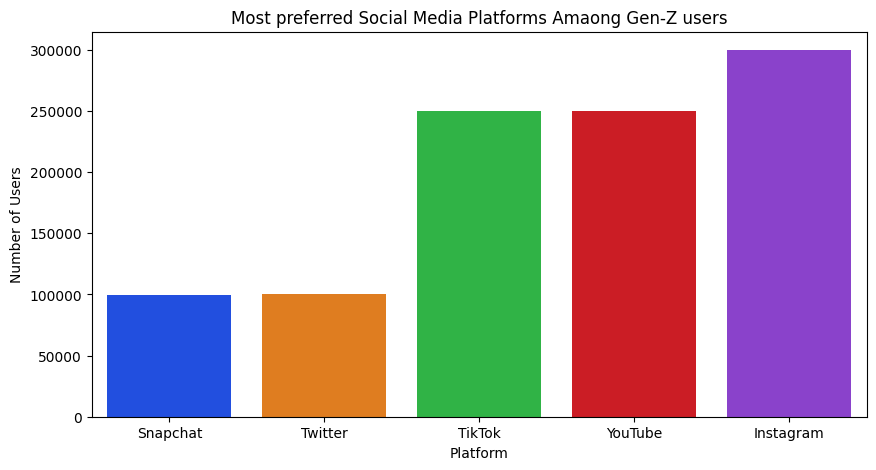

In [147]:
plt.figure(figsize=(10,5))

sns.countplot(
    data = df,
     x='primary_platform',
    palette = 'bright' 
)
plt.title('Most preferred Social Media Platforms Amaong Gen-Z users')
plt.xlabel('Platform')
plt.ylabel('Number of Users')
plt.show()

### **Insight:** 

* #### Instagram is the most preferred social media platform among Gen-Z users.
* #### TikTok and YouTube have almost equal levels of popularity.
* #### Snapchat and Twitter are the least preferred platforms, with nearly equal user counts.
* #### Overall, platform preference is not evenly distributed, with Instagram, TikTok, and YouTube being more dominant. 

* ### **Number of Social Media Platforms Used**

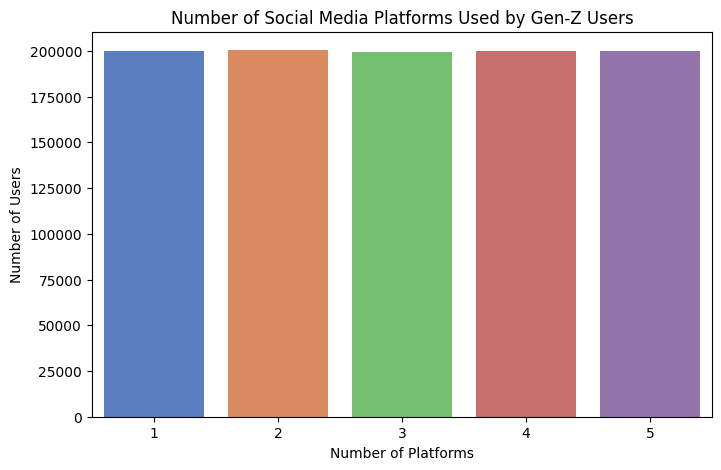

In [148]:
plt.figure(figsize=(8,5))

sns.countplot(
    data = df,
     x='num_platforms_used',
     palette = 'muted'
)
plt.title('Number of Social Media Platforms Used by Gen-Z Users')
plt.xlabel('Number of Platforms')
plt.ylabel('Number of Users')
plt.show()

 ### **Insight:**

* #### Users are almost equally distributed across all categories of platform usage, from 1 to 5 platforms.
* #### No single number of platforms has a significantly higher or lower frequency.
* #### Overall, the distribution is highly balanced, indicating diverse social media usage habits among users.

* ### **Purpose of Social Media Usage**

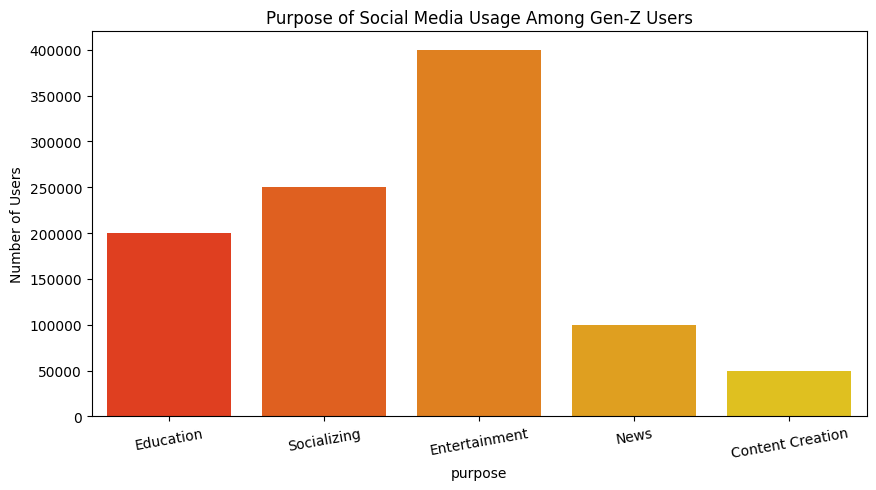

In [149]:
plt.figure(figsize=(10,5))

sns.countplot(
    data = df,
     x='purpose',
    palette = 'autumn'
)
plt.title('Purpose of Social Media Usage Among Gen-Z Users')
plt.xlabel('purpose')
plt.ylabel('Number of Users')
plt.xticks(rotation=10)
plt.show()

 ### **Insight:**
* #### Entertainment is the most common purpose for social media usage among Gen-Z users.
* #### Socializing and education are also significant reasons for using social media.
* #### News consumption and content creation are comparatively less common.
* #### Overall, the distribution suggests that Gen-Z users primarily use social media for entertainment and social interaction.

* ### **Average Session Duration**

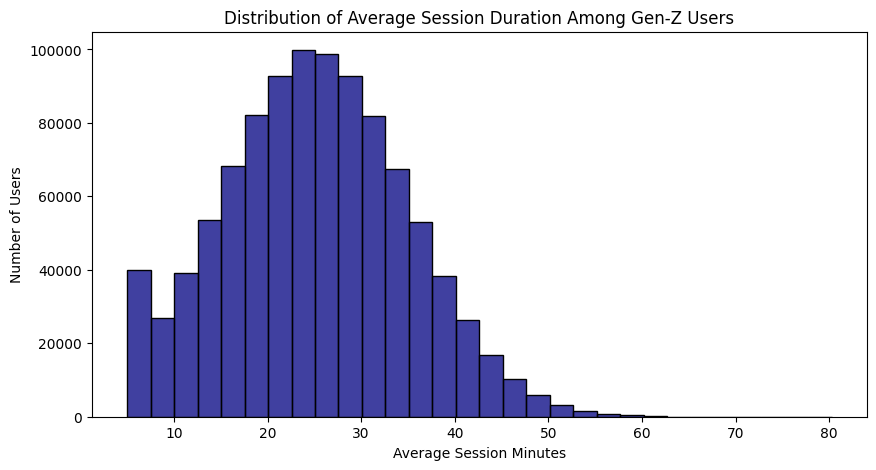

In [150]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x= 'avg_session_minutes',
    bins=30,
    color = 'navy'
)
plt.title('Distribution of Average Session Duration Among Gen-Z Users')
plt.xlabel('Average Session Minutes')
plt.ylabel('Number of Users')

plt.show()

 ### **Insight:**
* #### Most Gen-Z users have an average social media session duration between approximately 20 and 30 minutes.
* #### The distribution is positively (right) skewed, indicating a small number of users have considerably longer session durations.
* #### Users with an average session duration above 50 minutes are relatively uncommon.

* ### **Night-time Social Media Usage**


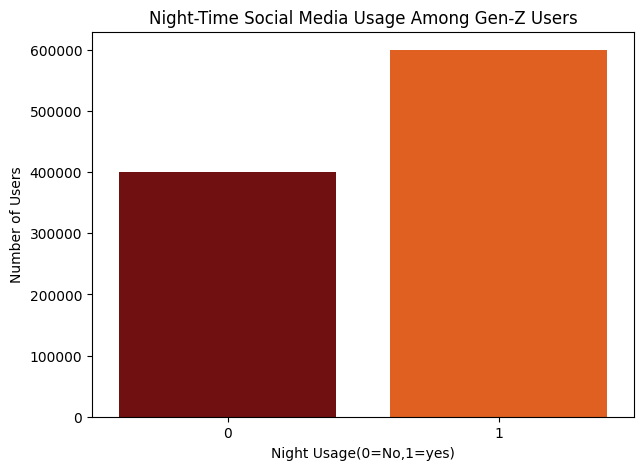

In [151]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x= 'night_usage',
    palette = 'gist_heat'
)
plt.title('Night-Time Social Media Usage Among Gen-Z Users')
plt.xlabel('Night Usage(0=No,1=yes)')
plt.ylabel('Number of Users')

plt.show()

### **Insight:** 
#### A larger proportion of Gen-Z users engage in social media during night-time compared to those who do not. Approximately 60% of users report night-time usage, while around 40% do not, indicating that late-night social media activity is relatively common among Gen-Z users.*



* ### **Mental Health Score Distribution**


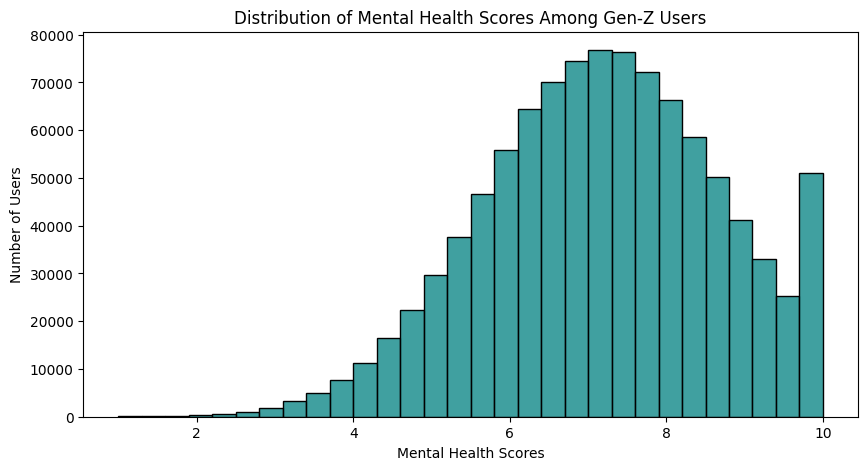

In [152]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x= 'mental_health_score',
    bins=30,
    color = 'teal'
    
)
plt.title('Distribution of Mental Health Scores Among Gen-Z Users')
plt.xlabel('Mental Health Scores')
plt.ylabel('Number of Users')

plt.show()

### **Insight:**

* #### The distribution of mental health scores is concentrated mainly between 6 and 9, with a peak around 7–8. 
* #### This suggests that a large proportion of Gen-Z users in the dataset demonstrate moderate to relatively high levels of well-being.
* #### However, a noticeable smaller group falls on the lower end of the scale, indicating that well-being experiences may vary significantly across users.


* ### **Social Media Addiction Level**

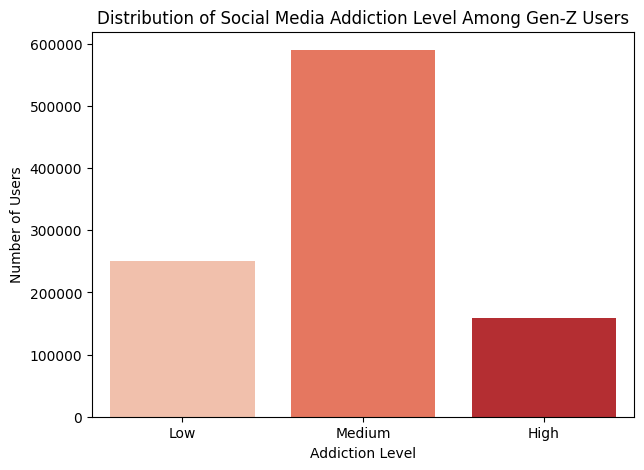

In [153]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x= 'addiction_level',
    order= ['Low','Medium','High'],
    palette = 'Reds'
)
plt.title('Distribution of Social Media Addiction Level Among Gen-Z Users')
plt.xlabel('Addiction Level')
plt.ylabel('Number of Users')

plt.show()

### **Insight**
* #### Medium addiction level dominates the dataset, with approximately 60% of Gen-Z users falling into this category.
* #### Low addiction accounts for roughly one-quarter of users, while High addiction represents the smallest group.
* #### This suggests that social media usage among the sampled Gen-Z population is predominantly moderate rather than extreme.
* #### However, the presence of a notable high-addiction group indicates that excessive usage patterns still affect a significant subset of users and can be explored further in relation to screen time, night usage, and mental well-being.

* ### **Screen Time Before Sleep**

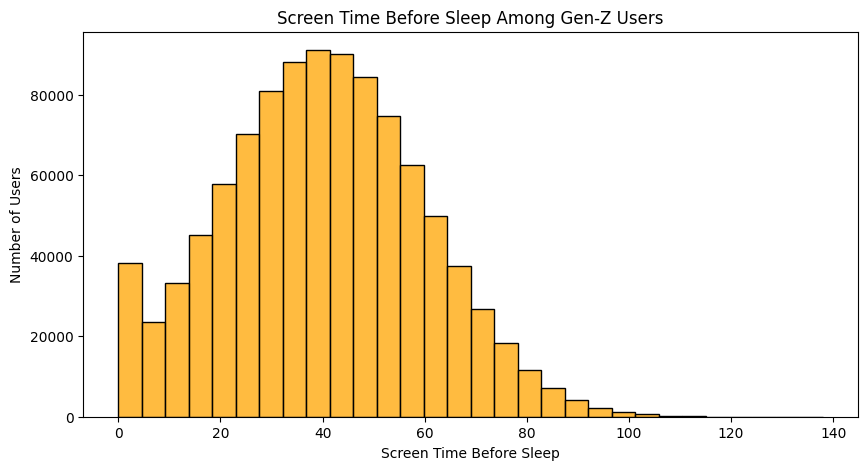

In [154]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x= 'screen_time_before_sleep',
    kde = False,
    bins=30,
    color = 'orange'
)
plt.title('Screen Time Before Sleep Among Gen-Z Users')
plt.xlabel('Screen Time Before Sleep')
plt.ylabel('Number of Users')

plt.show()

### **Insight:**

* #### Most Gen-Z users appear to spend approximately 30–60 minutes on social media before going to sleep, with the highest concentration around 40–45 minutes. 
* #### The distribution is right-skewed, indicating that while moderate pre-sleep screen usage is common, a smaller group of users spends substantially longer periods on social media before bedtime.

## 3.2 Bivariate Analysis

* ### **Purpose of Social Media Usage Across Different Countries**

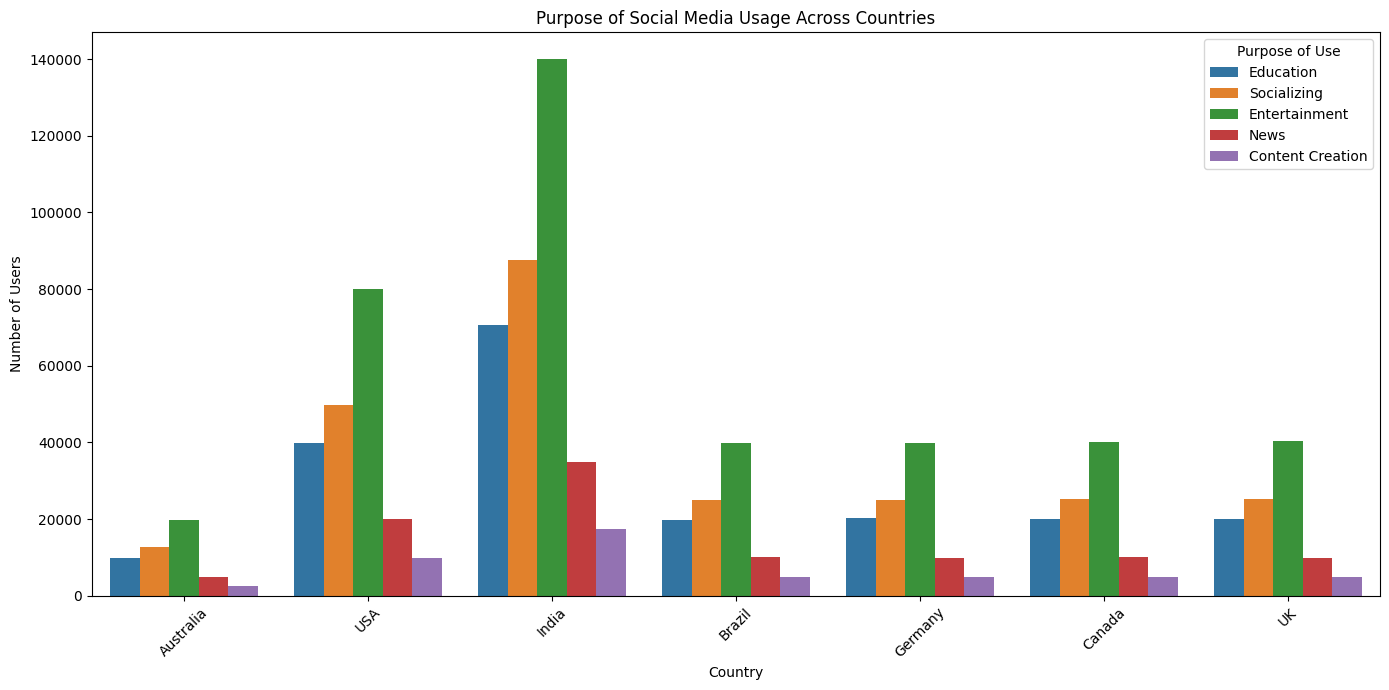

In [155]:
plt.figure(figsize=(14, 7))

sns.countplot(
    data=df,
    x='country',
    hue='purpose',
    
)

plt.title('Purpose of Social Media Usage Across Countries')
plt.xlabel('Country')
plt.ylabel('Number of Users')
plt.xticks(rotation=45)
plt.legend(title='Purpose of Use')

plt.tight_layout()
plt.show()

### **Insight:**
* #### Entertainment is the most common purpose of social media usage across all countries shown in the dataset.
* #### India has the highest number of users across almost every purpose, especially for entertainment, followed by the USA.
* #### Socializing is generally the second most popular purpose, while Education has comparatively fewer users.
* #### News and Content Creation have the lowest user counts across most countries.
* #### Overall, the graph shows that user behavior is broadly similar across countries, with Entertainment dominating social media usage, although the total number of users varies significantly by country.

* ### **Primary Social Media Platform Usage by Gender**

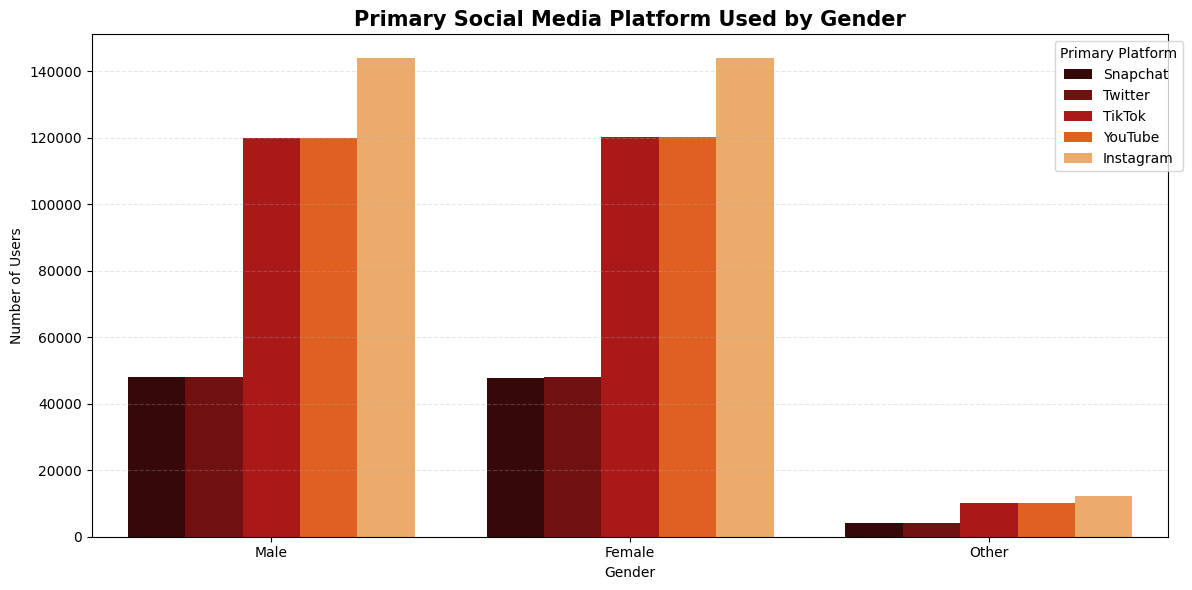

In [156]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    x='gender',
    hue='primary_platform',
    palette='gist_heat'
)

plt.title('Primary Social Media Platform Used by Gender',
          fontsize=15, fontweight='bold')

plt.xlabel('Gender')
plt.ylabel('Number of Users')

plt.legend(title='Primary Platform', bbox_to_anchor=(1.02, 1))
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### **Insight:** 
#### Instagram emerges as the most popular primary social media platform among both male and female users, followed by TikTok and YouTube. Overall, platform preferences show a similar pattern across genders, while Snapchat and Twitter have comparatively lower usage.

* ### **Relation Between Daily Social Media Usage And Mental Health Score**

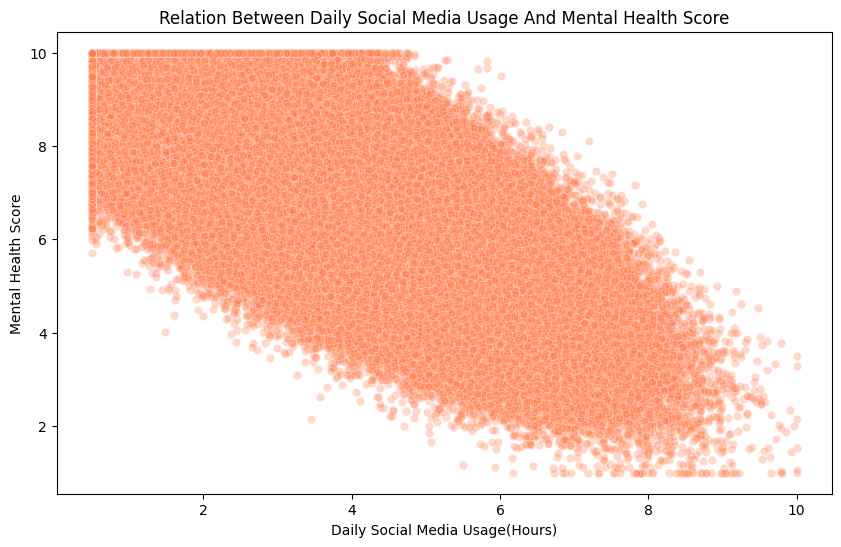

In [7]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='daily_usage_hours',
    y='mental_health_score',
    alpha = 0.3,
    color = 'coral'   
)
plt.title('Relation Between Daily Social Media Usage And Mental Health Score')
plt.xlabel('Daily Social Media Usage(Hours)')
plt.ylabel('Mental Health Score')

plt.show()


### **Insight:**
* #### A noticeable negative relationship is observed between daily social media usage and mental health scores.
* #### Higher usage hours generally correspond to lower mental well-being scores, suggesting a potential association between excessive social media use and reduced mental well-being.

* ### **Relation Between Screen Time Before Sleep and Mental Health Score**

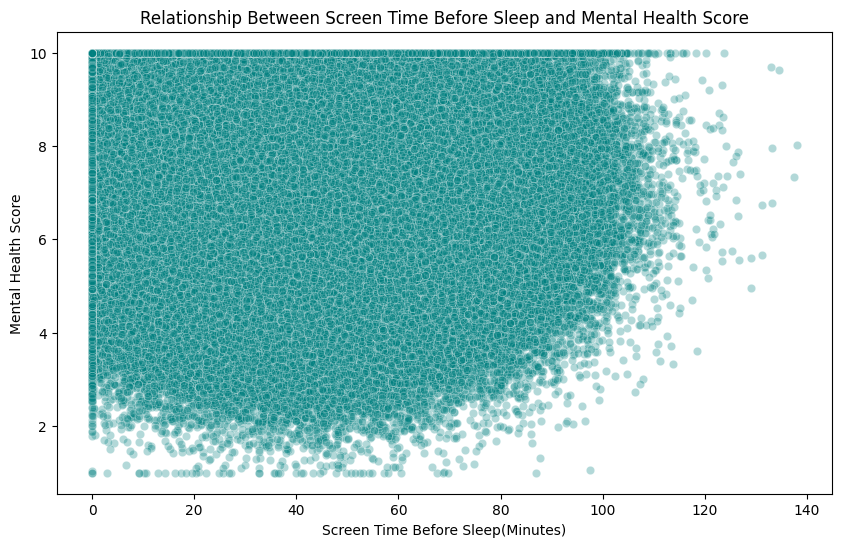

In [158]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='screen_time_before_sleep',
    y= 'mental_health_score',
    alpha = 0.3,
    color = 'Teal'
)

plt.title('Relationship Between Screen Time Before Sleep and Mental Health Score')
plt.xlabel('Screen Time Before Sleep(Minutes)')
plt.ylabel('Mental Health Score')
plt.show()


### **Insight:**

* #### The scatter plot suggests a negative association between screen time before sleep and mental health scores. As the time spent on social media before sleeping increases, users tend to show lower mental well-being scores.
* #### Late night screen exposure appears to be associated with reduced mental well-being in this dataset. However, this visualization shows an association only and does not establish causation.

* ### **Social Media Addiction Level and Daily Social Media Usage** 


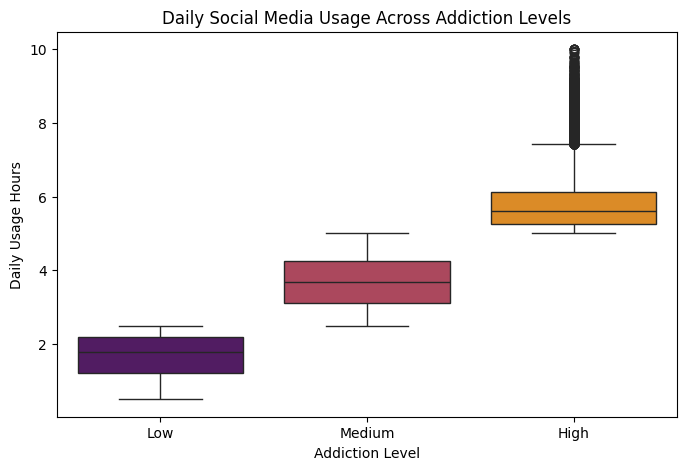

In [159]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='addiction_level',
    y= 'daily_usage_hours',
    order =['Low','Medium','High'],
    palette = 'inferno'
)

plt.title('Daily Social Media Usage Across Addiction Levels')
plt.xlabel('Addiction Level')
plt.ylabel('Daily Usage Hours')
plt.show()

### **Insight:**
* #### The visualization shows a clear increase in daily social media usage as addiction level rises.
* #### Users with low addiction levels have the lowest median daily usage, followed by medium-level users, while highly addicted users spend the most time on social media.
* #### This suggests a strong positive association between social media usage intensity and addiction level. A few high-usage observations are also visible within the high addiction category.

* ### **Screen Time Before Sleep Accors different Social Media addiction levels**

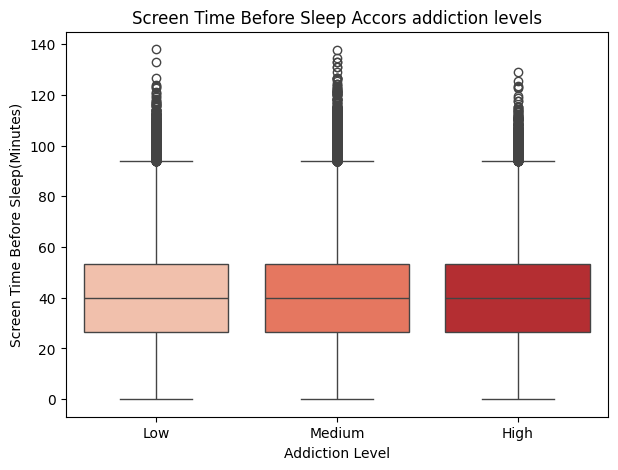

In [160]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='addiction_level',
    y= 'screen_time_before_sleep',
    order =['Low','Medium','High'],
    palette = 'Reds'
)

plt.title('Screen Time Before Sleep Accors addiction levels')
plt.xlabel('Addiction Level')
plt.ylabel('Screen Time Before Sleep(Minutes)')
plt.show()

### **Insight:**
* #### The visualization shows that screen time before sleep has a slight increasing trend across addiction levels.
* #### Users with high addiction levels appear to have a marginally higher median screen time before sleep compared to users with low and medium addiction levels.
* #### However, the distributions overlap considerably, suggesting that screen time before sleep alone may not strongly differentiate addiction levels.
* #### The presence of several high-value observations across all categories also indicates that excessive pre-sleep screen usage occurs regardless of addiction category.

* ### **Mental Health Score Across Different Social Media Addiction Levels**

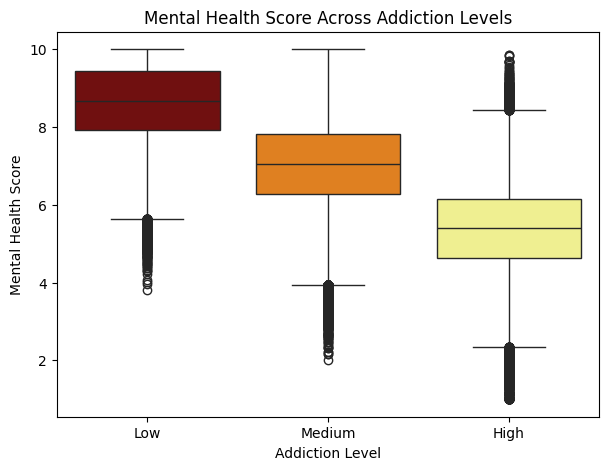

In [54]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='addiction_level',
    y= 'mental_health_score',
    order =['Low','Medium','High'],
    palette = 'afmhot'
)

plt.title('Mental Health Score Across Addiction Levels')
plt.xlabel('Addiction Level')
plt.ylabel('Mental Health Score')
plt.show()

### **Insight**
* #### The visualization shows a clear decline in mental health scores as social media addiction levels increase.
* #### Users with low addiction levels have the highest median mental health scores, followed by those with medium addiction levels, while highly addicted users show the lowest median scores.
* #### This consistent downward trend suggests a strong negative relationship between social media addiction intensity and mental well-being.
* #### Although some observations overlap across the groups, the overall pattern indicates that higher addiction levels are associated with poorer mental health scores.

## 3.3 Correlation Analysis

* ### **Correlation Between Numerical Features**

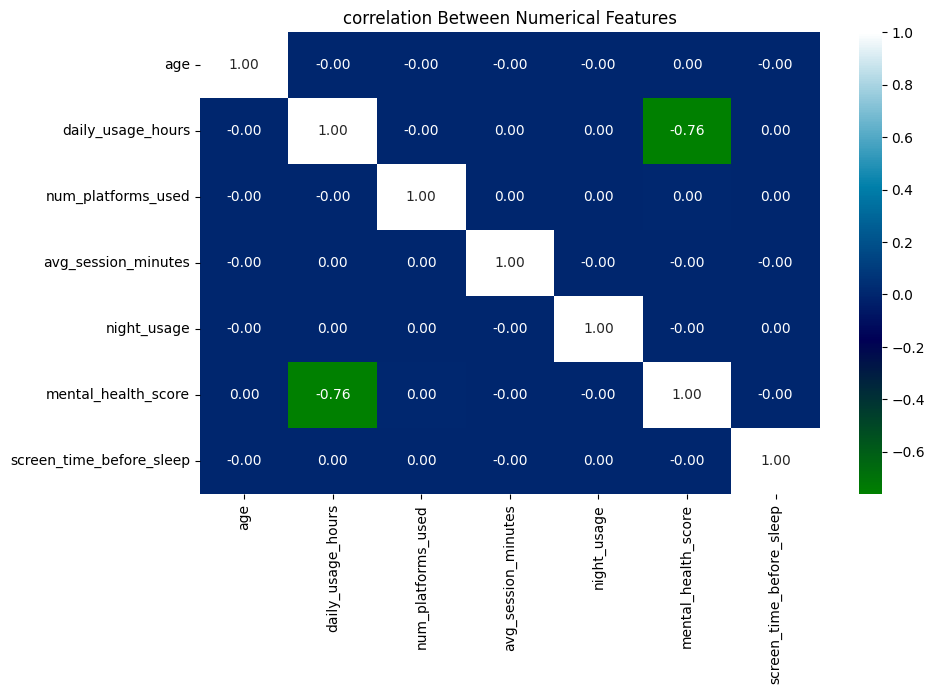

In [85]:
plt.figure(figsize=(10,6))
numerical_cols = df.select_dtypes(include='number')

sns.heatmap(
    numerical_cols.corr(),
    annot=True,
    cmap='ocean',
    fmt='.2f'
)

plt.title('correlation Between Numerical Features')
plt.show()

### **Correlation Analysis Insight**

* #### The correlation heatmap reveals that most numerical variables have little to no linear relationship with each other, as their correlation coefficients are close to zero.
* #### However, daily social media usage hours and mental health score show a strong negative correlation of -0.76.
* #### This indicates that higher daily social media usage is strongly associated with lower mental health scores in this dataset.
*  #### Other variables, including age, number of platforms used, average session duration, night usage, and screen time before sleep, show negligible linear correlations with the remaining numerical features.

## 3.4 Multivariate Analysis

* ### **Relation Between Daily Social Media Usage , Mental Health Score and Addiction Level**

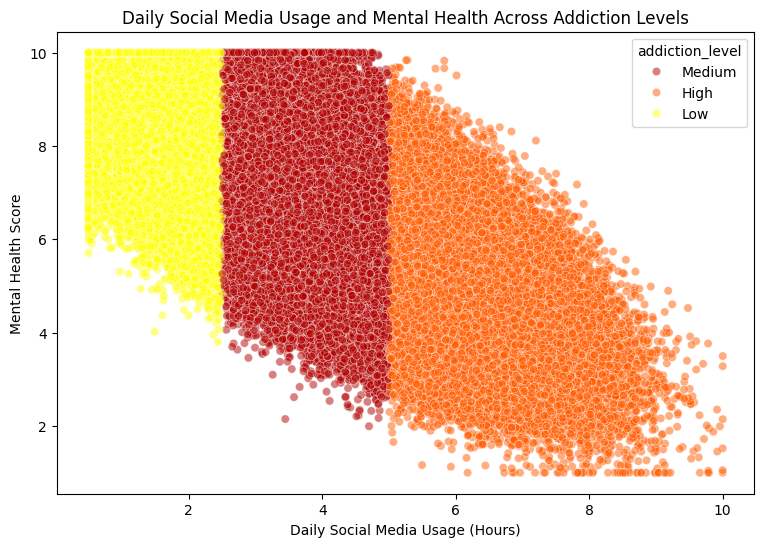

In [90]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x='daily_usage_hours',
    y='mental_health_score',
    hue='addiction_level',
    alpha=0.5,
    palette='hot'
)

plt.title('Daily Social Media Usage and Mental Health Across Addiction Levels')
plt.xlabel('Daily Social Media Usage (Hours)')
plt.ylabel('Mental Health Score')

plt.show()

### **Insight**

* #### The visualization reveals a clear pattern across different addiction levels. Users with low addiction levels are concentrated at lower daily social media usage and generally higher mental health scores. 
* #### As addiction levels increase from low to medium and high, daily usage shifts upward while mental health scores tend to decline. 
* #### The high addiction group shows the highest social media usage along with comparatively lower mental health scores. Overall, the visualization suggests that increased social media usage and higher addiction levels are associated with poorer mental health outcomes.

* ### **Gender-wise Addiction and Mental Health Analysis**

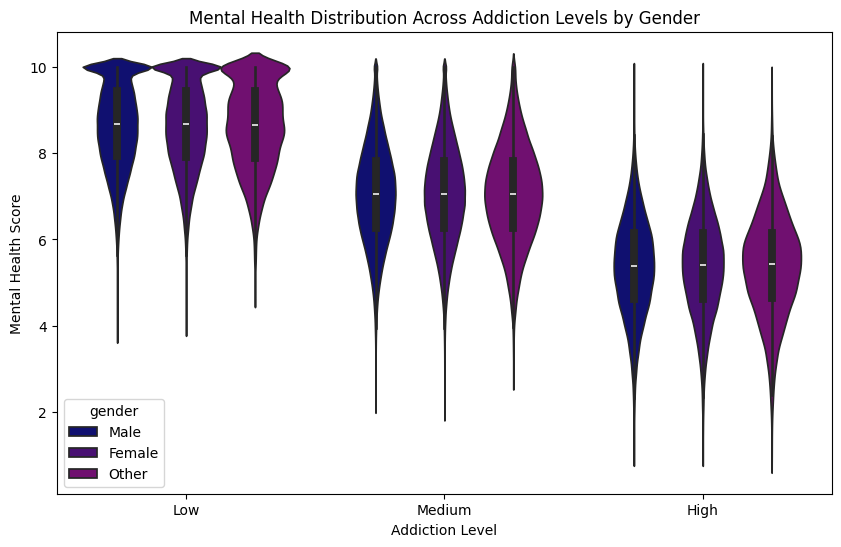

In [91]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=df,
    x='addiction_level',
    y='mental_health_score',
    hue='gender',
    order=['Low', 'Medium', 'High'],
    inner='box',
    palette=['navy','indigo','purple']
)

plt.title('Mental Health Distribution Across Addiction Levels by Gender')
plt.xlabel('Addiction Level')
plt.ylabel('Mental Health Score')

plt.show()

### **Insight:**
* #### The visualization shows a clear relationship between addiction level and mental health score across all gender groups.
* #### Users with Low addiction levels tend to have the highest mental health scores, while those with High addiction levels show the lowest scores.
* #### The Medium addiction group falls between the Low and High groups, suggesting a gradual decline in mental health as addiction level increases.
* #### This overall pattern appears consistent across Male, Female, and Other genders, with only minor differences in the distributions.


* ### **Age-wise Mental Health Score Across Addiction Levels**

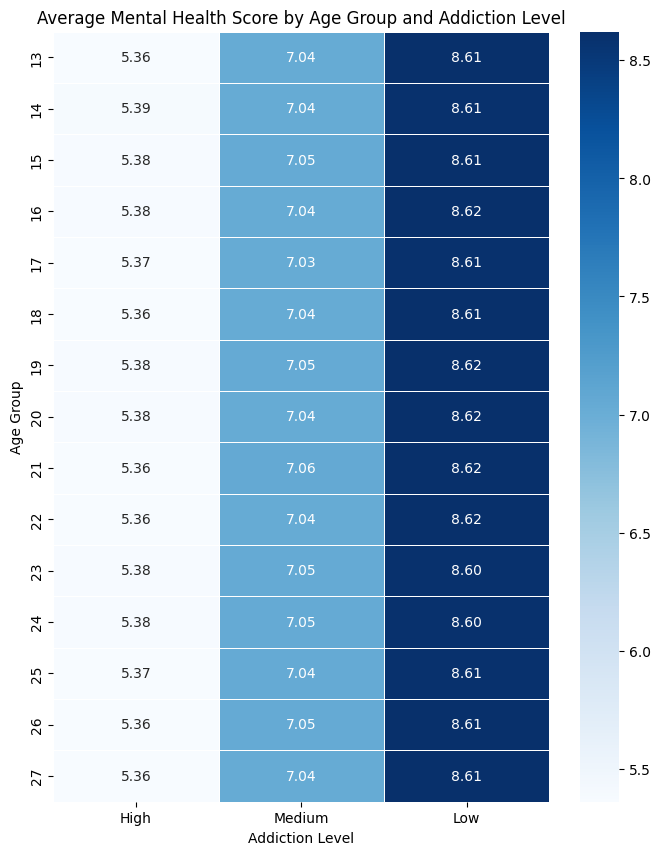

In [130]:

addiction_order = ['High', 'Medium', 'Low']

heatmap_data = df.pivot_table(
    index='age',
    columns='addiction_level',
    values='mental_health_score',
    aggfunc='mean'
)

heatmap_data = heatmap_data[addiction_order]

plt.figure(figsize=(8, 10))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    linewidths=0.5
)

plt.title('Average Mental Health Score by Age Group and Addiction Level')
plt.xlabel('Addiction Level')
plt.ylabel('Age Group')

plt.show()

### **Insight:**
* #### Mental health scores show a strong inverse relationship with addiction level.
* #### Across all age groups, lower addiction levels are associated with better mental health scores, while higher addiction levels correspond to lower scores.
* #### Age-wise variations appear minimal compared to the impact of addiction level.

* ### **Mental Health Score of Night Usage By Age**

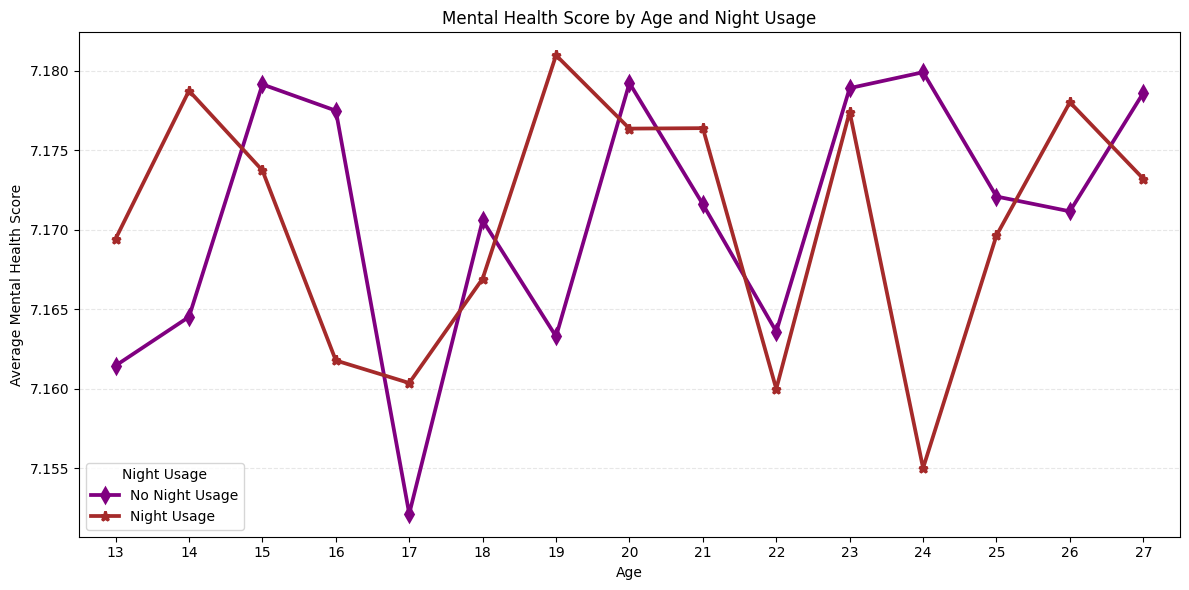

In [11]:
plt.figure(figsize=(12, 6))

sns.pointplot(
    data=df,
    x='age',
    y='mental_health_score',
    hue='night_usage',
    errorbar=None,
    markers=['d', '*'],
    palette = ['purple','brown']
)

plt.title('Mental Health Score by Age and Night Usage')

plt.xlabel('Age')
plt.ylabel('Average Mental Health Score')

plt.legend(
    title='Night Usage',
    labels=['No Night Usage', 'Night Usage']
)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

### **Insight:**
* #### Average mental health scores remain fairly consistent across ages for both night users and non-night users.
* #### Although small fluctuations exist at certain ages, there is no clear or consistent pattern showing that night usage significantly affects mental health across different age groups.

# 4. Key Insights

* ### Social media usage shows a strong relationship with mental well-being. Daily social media usage hours and mental health scores have a strong negative correlation of approximately -0.76, making it the most significant relationship identified in the analysis.
* ### Social media addiction emerges as another important factor. As addiction levels increase from Low to Medium and High, daily usage tends to increase while mental health scores consistently decline.
* ### The relationship between addiction and mental health remains consistent across demographic groups. Gender and age show relatively minor variations compared to the strong impact of addiction level on mental health.
* ### Night-time usage is common among Gen-Z users, with around 60% of users engaging with social media at night. However, the analysis does not show a strong or consistent relationship between night usage and mental health across different age groups.
* ### Pre-sleep screen time shows a negative association with mental health. Users who spend longer periods on social media before sleeping tend to have comparatively lower mental health scores.
* ### Entertainment is the dominant purpose of social media usage across all countries, followed by socializing. Instagram is the most preferred primary platform among both male and female users.
* ### Most users demonstrate moderate social media addiction, while high addiction represents a smaller but important group associated with the highest usage intensity and lowest mental health scores.
* ### Geographical differences mainly affect user representation rather than overall behavior patterns. Despite differences in the number of users across countries, entertainment remains the dominant purpose of social media usage.

# 5. Conclusion
* ### This exploratory data analysis highlights the complex relationship between Gen-Z's digital habits, social media addiction, and mental well-being. The findings suggest that higher daily social media usage and increased addiction levels are strongly associated with lower mental health scores. Among all the numerical relationships explored, daily social media usage demonstrated the strongest negative correlation with mental health.
* ### While factors such as night-time usage, age, gender, and the number of platforms used showed relatively smaller variations, usage intensity and addiction level emerged as the most influential patterns in the dataset. Additionally, longer screen exposure before sleep was associated with lower mental well-being, emphasizing the potential importance of healthy digital habits.
* ### Overall, this analysis does not establish causation, but it reveals meaningful associations between excessive social media engagement and mental health outcomes. These findings provide a foundation for further analysis and future interactive dashboards to explore digital behavior patterns in greater depth.